Try using a denoising autoencoder to pretrain an image classifier. You
can use MNIST (the simplest option), or a more complex image dataset
such as CIFAR10 if you want a bigger challenge. Regardless of the
dataset you’re using, follow these steps

a. Split the dataset into a training set and a test set. Train a deep
denoising autoencoder on the full training set.

b. Check that the images are fairly well reconstructed. Visualize the
images that most activate each neuron in the coding layer.

c. Build a classification DNN, reusing the lower layers of the
autoencoder. Train it using only 500 images from the training set.
Does it perform better with or without pretraining?

In [1]:
%pip install tensorflow
%pip install numpy
%pip install matplotlib

In [2]:
!nvidia-smi -L
import tensorflow as tf
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

GPU 0: NVIDIA H100 80GB HBM3 (UUID: GPU-76f3c895-9db5-0ba6-3f51-ab40ba635aab)
TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras import mixed_precision

# Acelera en Tensor Cores (H100)
mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)  # XLA

gpus = tf.config.list_physical_devices("GPU")
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()


El conjunto de datos CIFAR-10 consta de 60.000 imágenes a color de 32x32 en 10 clases, con 6.000 imágenes por clase. Hay 50.000 imágenes de entrenamiento y 10.000 imágenes de prueba.


In [5]:
import tensorflow as tf

tf.random.set_seed(42)
dataset = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [6]:
(x_train, y_train), (x_test, y_test) = dataset

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_val = x_train

print(x_train.shape)


(50000, 32, 32, 3)


In [7]:
print(x_train.shape)
print(x_val.shape)

(50000, 32, 32, 3)
(50000, 32, 32, 3)


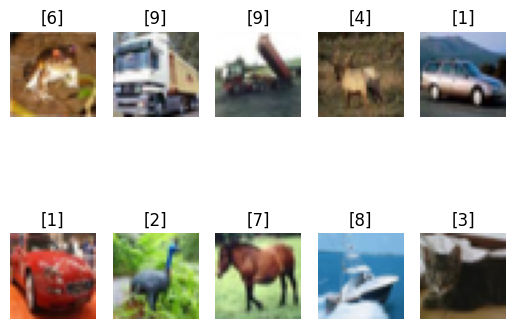

In [8]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [ ]:
encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32 * 32 * 3, activation="relu"),
    tf.keras.layers.Dense(5000, activation="relu"),
    tf.keras.layers.Dense(4000, activation="relu"),
    tf.keras.layers.Dense(3000, activation="relu"),
    tf.keras.layers.Dense(2000, activation="relu"),
    tf.keras.layers.Dense(1000, activation="relu"),
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu")
])

decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(1000, activation="relu"),
    tf.keras.layers.Dense(2000, activation="relu"),
    tf.keras.layers.Dense(3000, activation="relu"),
    tf.keras.layers.Dense(4000, activation="relu"),
    tf.keras.layers.Dense(5000, activation="relu"),
    tf.keras.layers.Dense(32 * 32 * 3, activation="sigmoid"),
    tf.keras.layers.Reshape([32, 32, 3])
])

autoencoder = tf.keras.Sequential([encoder, decoder])

In [10]:
from tensorflow.python.data import AUTOTUNE
BATCH_SIZE = 128

def add_noise(x, sigma=0.5):
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=sigma)
    return tf.clip_by_value(x + noise, 0.0, 1.0)

def make_ds(x, training=True):
    ds = tf.data.Dataset.from_tensor_slices(x)
    if training:
        ds = ds.shuffle(10000)
    ds = ds.map(lambda clean: (add_noise(clean), clean), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(x_train, training=True)
val_ds   = make_ds(x_val, training=False)
test_ds  = make_ds(x_test, training=False)

In [11]:
with strategy.scope():
    autoencoder.compile(loss="binary_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=0.002))

history = autoencoder.fit(train_ds, validation_data=val_ds, epochs=125)

Epoch 1/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 101s 163ms/step - loss: 0.6949 - val_loss: 0.6892
Epoch 2/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 3/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 4/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 5/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 6/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 7/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6892
Epoch 8/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 9/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 10/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6892 - val_loss: 0.6891
Epoch 11/125
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6891
Epoch 12/125
391/391 ━━━━━━━━━━━━━━━━

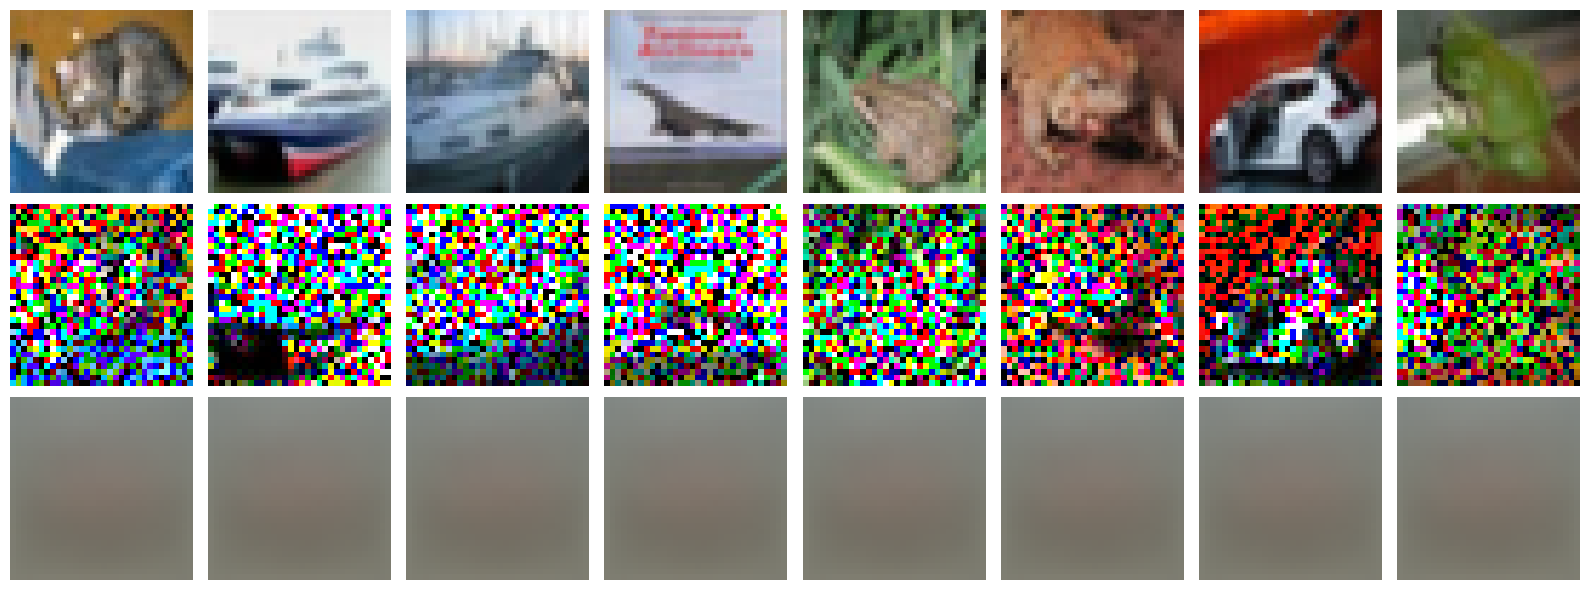

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_denoised_images(autoencoder, x_test, n=8, dropout_rate=0.5):
    clean = x_test[:n]
    noisy = tf.clip_by_value(clean + 0.15 * tf.random.normal(tf.shape(clean)), 0.0, 1.0)

    denoised = autoencoder.predict(noisy, verbose=0)

    # 👇 cast a float32 para matplotlib
    clean = clean.astype(np.float32)
    noisy = noisy.numpy().astype(np.float32)
    denoised = denoised.astype(np.float32)

    dropout = tf.keras.layers.Dropout(dropout_rate)
    noisy  = dropout(clean, training=True)

    noisy = noisy.numpy().astype(np.float32)

    fig, ax = plt.subplots(3, n, figsize=(2*n, 6))
    for i in range(n):
        ax[0, i].imshow(np.clip(clean[i], 0, 1));    ax[0, i].axis("off")
        ax[1, i].imshow(np.clip(noisy[i], 0, 1));    ax[1, i].axis("off")
        ax[2, i].imshow(np.clip(denoised[i], 0, 1)); ax[2, i].axis("off")
    plt.tight_layout()
    plt.show()

plot_denoised_images(autoencoder, x_test)


In [90]:


with strategy.scope():
    encoder = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu"),
        tf.keras.layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")
    ])

    decoder = tf.keras.Sequential([
        tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu"),
        tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu"),
        tf.keras.layers.Conv2D(3, 3, padding="same", activation="sigmoid")
    ])

    model = tf.keras.Sequential([encoder, decoder])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0249 - val_loss: 0.0121
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0120 - val_loss: 0.0116
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0113 - val_loss: 0.0115
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0109 - val_loss: 0.0108
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0107 - val_loss: 0.0107
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0105 - val_loss: 0.0104
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0104 - val_loss: 0.0104
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0104 - val_loss: 0.0104
Epoch 9/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0103 - val_loss: 0.0102
Epoch 10/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - val_loss: 0.0102
Epoch 11/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - val_loss: 0.0103
Epoch 12/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/st

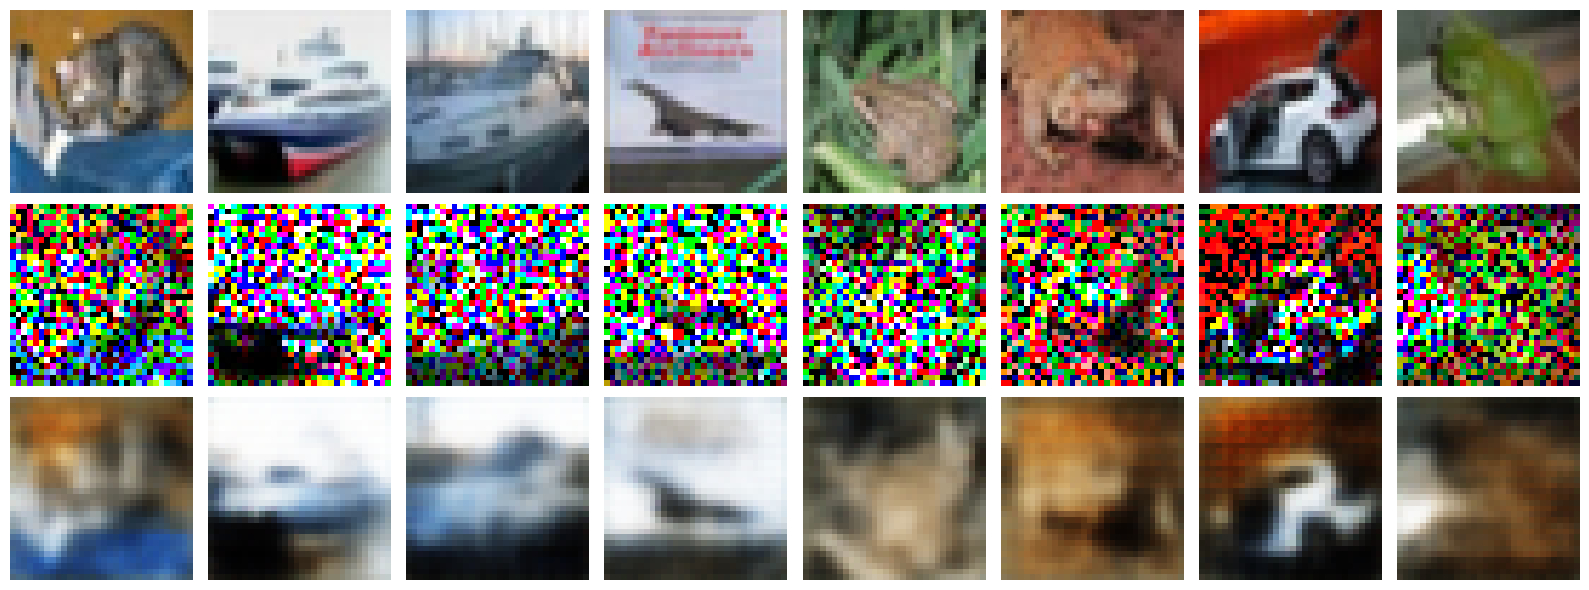

In [73]:
plot_denoised_images(model, x_test)


Clearly, the convolutional outperforms the dense layers autoencoder by far

Now lets reuse this autoencoder on a classification DNN

In [ ]:
classifier = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10, activation="softmax")
])

print(x_train.shape)
print(y_train.shape)

training_x = x_train[:500, :] / 255.
training_y = y_train[:500, :]


test_x = x_test[:500] / 255.
test_y = y_test[:500]

train_dataset = tf.data.Dataset.from_tensor_slices((training_x, tf.squeeze(training_y))).shuffle(500).batch(10)

classifier.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
classifier.fit(train_dataset, validation_data=(test_x, tf.squeeze(test_y)))

(50000, 32, 32, 3)
(50000, 1)
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.1062 - loss: 2.3711 - val_accuracy: 0.0820 - val_loss: 2.3035
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1270 - loss: 2.2878 - val_accuracy: 0.1080 - val_loss: 2.3225
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1994 - loss: 2.1810 - val_accuracy: 0.0800 - val_loss: 2.4777
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2204 - loss: 2.0588 - val_accuracy: 0.0800 - val_loss: 2.7244
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2543 - loss: 2.0113 - val_accuracy: 0.1080 - val_loss: 3.0286
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2549 - loss: 2.0347 - val_accuracy: 0.0800 - val_loss: 4.0958
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2013 - loss: 2.0558 - val_accuracy: 0.0800 - val_loss: 3.8876
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2398 - loss: 1.8600 - v

In [93]:
reused_weights = encoder
reused_weights.trainable = False
cloned_layers_autoencoders = tf.keras.Sequential([
    reused_weights,
    tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(1024, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10, activation="softmax")
])

print(x_train.shape)
print(y_train.shape)

training_x = x_train[:500, :] / 255.
training_y = y_train[:500, :]

test_x = x_test[:500] / 255.
test_y = y_test[:500]

train_dataset = tf.data.Dataset.from_tensor_slices((training_x, tf.squeeze(training_y))).shuffle(500).batch(10)

cloned_layers_autoencoders.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cloned_layers_autoencoders.fit(train_dataset, validation_data=(test_x, test_y), epochs=50)

(50000, 32, 32, 3)
(50000, 1)
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.1233 - loss: 4.1026 - val_accuracy: 0.0820 - val_loss: 2.3268
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1795 - loss: 2.1495 - val_accuracy: 0.1080 - val_loss: 2.4553
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2504 - loss: 1.9683 - val_accuracy: 0.1080 - val_loss: 2.6362
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2893 - loss: 1.8476 - val_accuracy: 0.1080 - val_loss: 2.7629
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3399 - loss: 1.7540 - val_accuracy: 0.0940 - val_loss: 2.7484
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3418 - loss: 1.6703 - val_accuracy: 0.1020 - val_loss: 2.6208
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3331 - loss: 1.7037 - val_accuracy: 0.1020 - val_loss: 3.0720
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4429 - loss: 1.4875 - v